# PHÂN TÍCH KHÁM PHÁ DỮ LIỆU RƯỢU VANG (EXPLORATORY DATA ANALYSIS)

Dự án: **Phân tích và Đối sánh Chất lượng Rượu Vang (Wine Quality Analysis)**  
Tham chiếu cấu trúc & trực quan hóa từ Kaggle Starter Notebook: `starter-red-wine-quality-013eab7b-e.ipynb`

Notebook này cung cấp:
1. **Sơ đồ phân phối theo hàng và cột (Distribution graphs per column & row)**
2. **Ma trận tương quan dạng lưới ma trận (Correlation matrix with matshow)**
3. **Ma trận phân tán và mật độ (Scatter and density plots with KDE & Correlation annotations)**
4. **Phân tích bóc tách các đặc trưng hóa lý then chốt của rượu vang**

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập đường dẫn root dự án
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from src.data_loader import doc_du_lieu_goc, doc_du_lieu_chuan
from src.visualizer import (
    plotPerColumnDistribution,
    plotCorrelationMatrix,
    plotScatterMatrix,
    ve_phan_phoi_chat_luong,
    ve_so_sanh_loai_ruou,
    ve_yeu_to_quyet_dinh_chat_luong,
    ve_tat_ca_bieu_do
)

%matplotlib inline
print("[INFO] Đã nạp thành công các module phân tích và trực quan hóa!")

[INFO] Đã nạp thành công các module phân tích và trực quan hóa!


## 1. Định Nghĩa Các Hàm Trực Quan Hóa Cốt Lõi (Kaggle Starter Functions)
Các hàm được chuẩn hóa theo đúng cấu trúc trong `starter-red-wine-quality-013eab7b-e.ipynb`:
- `plotPerColumnDistribution(df, nGraphShown, nGraphPerRow)`: Vẽ phân phối cột theo dạng lưới hàng-cột.
- `plotCorrelationMatrix(df, graphWidth)`: Vẽ ma trận tương quan bằng `plt.matshow` kèm thước màu.
- `plotScatterMatrix(df, plotSize, textSize)`: Vẽ ma trận phân tán scatter plot kèm đường mật độ KDE trên đường chéo và chú thích hệ số tương quan.

In [1]:
# 1. Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1]] # Giữ lại các cột có dữ liệu biến thiên
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = int((nCol + nGraphPerRow - 1) / nGraphPerRow)
    plt.figure(num = None, figsize = (4.5 * nGraphPerRow, 3.5 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)) or nunique[columnNames[i]] < 10:
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist(bins=25)
        plt.ylabel('counts')
        plt.xticks(rotation = 45, ha='right')
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

# 2. Correlation matrix
def plotCorrelationMatrix(df, graphWidth):
    filename = getattr(df, 'dataframeName', 'chatluong_ruougoc.csv')
    df = df.select_dtypes(include=[np.number]).dropna(axis='columns')
    df = df[[col for col in df if df[col].nunique() > 1]]
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum = 1, cmap='coolwarm')
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15, pad=20)
    plt.show()

# 3. Scatter and density plots
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number]).dropna(axis='columns')
    df = df[[col for col in df if df[col].nunique() > 1]]
    columnNames = list(df)
    if len(columnNames) > 8: # Chọn 8 cột tiêu biểu để ma trận KDE tính toán nhanh và rõ nét
        columnNames = columnNames[:8]
    df = df[columnNames]
    if len(df) > 1000:
        df = df.sample(n=1000, random_state=42)
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('Corr. coef = %.3f' % corrs[i, j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot', fontsize=16)
    plt.show()

## 2. Nạp Dữ Liệu Rượu Vang
Đọc dữ liệu thô `chatluong_ruougoc.csv` và dữ liệu chuẩn hóa `duleu_chuan.feather`.

In [1]:
df1 = doc_du_lieu_goc()
df1.dataframeName = 'chatluong_ruougoc.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')
df1.head(5)

There are 6497 rows and 13 columns


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,loai_ruou
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Vang đỏ
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Vang đỏ
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Vang đỏ
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Vang đỏ
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Vang đỏ


## 3. Sơ Đồ Phân Phối Theo Cột Hàng (Distribution Graphs of Column Data)
Hiển thị phân bố tần suất của từng chỉ số hóa lý và chất lượng theo bố cục lưới hàng và cột (4 biểu đồ mỗi hàng).

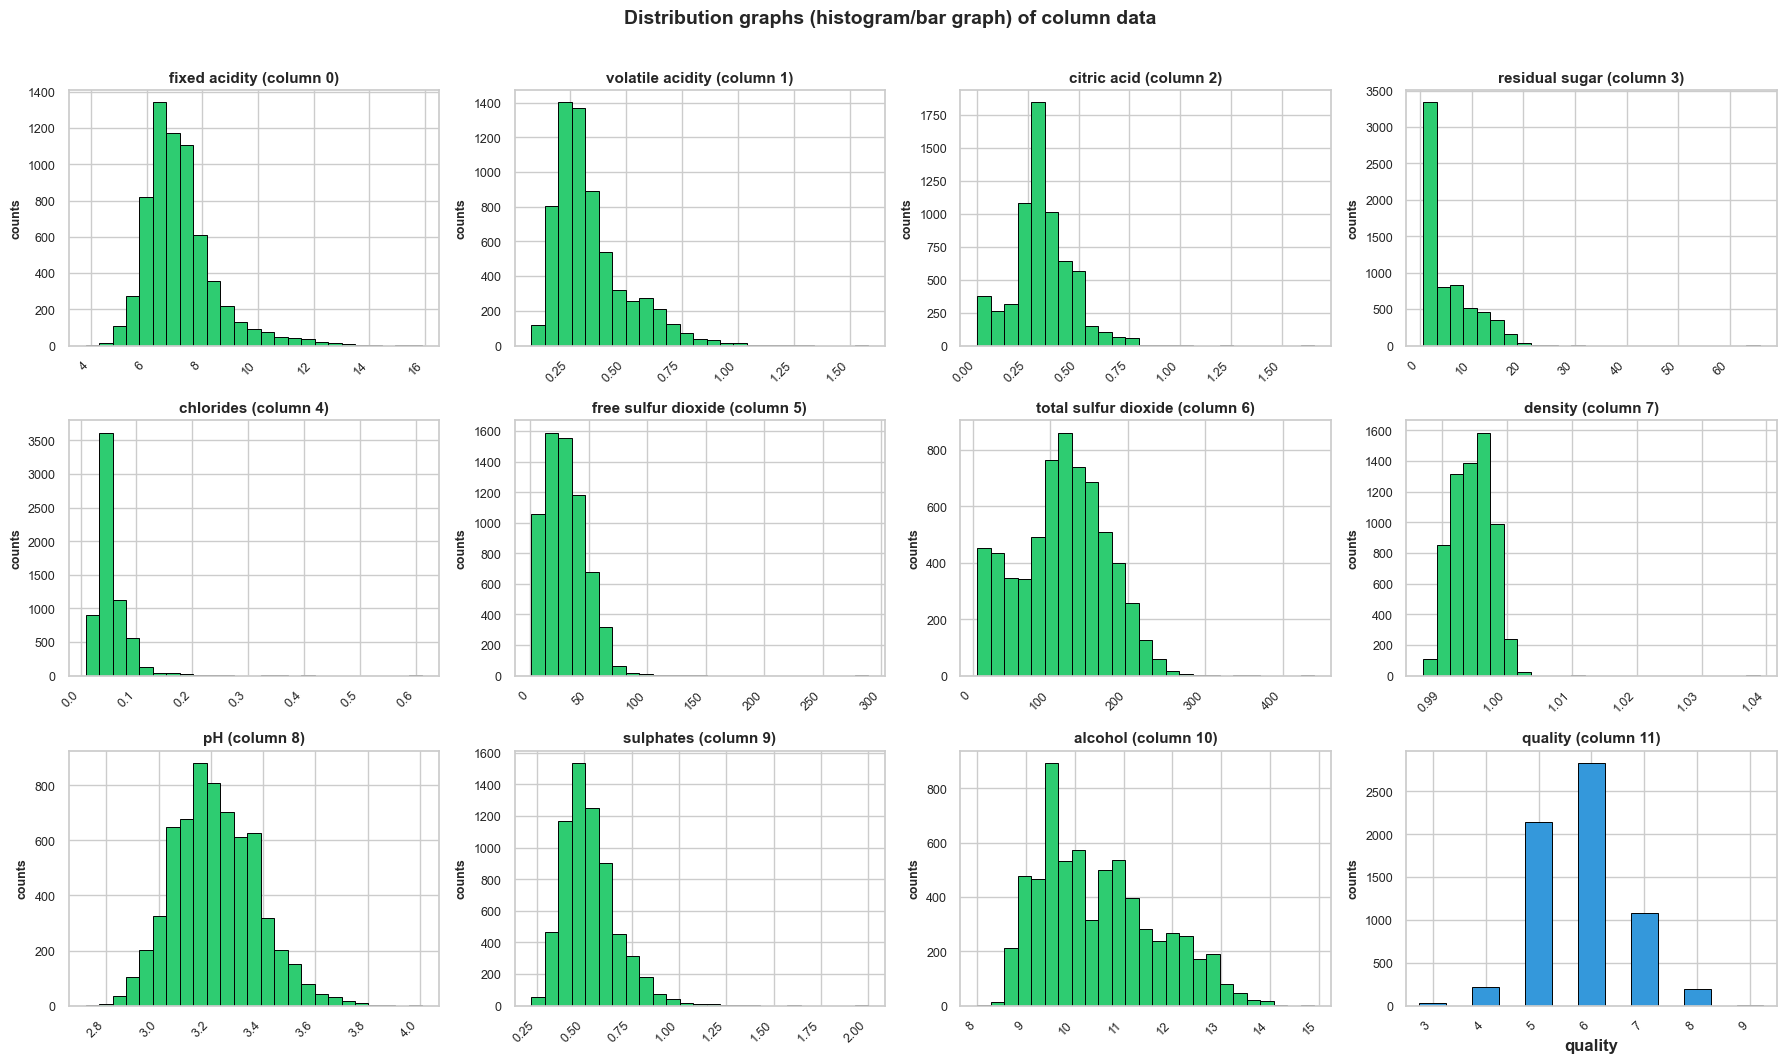

In [1]:
plotPerColumnDistribution(df1, 12, 4)

## 4. Ma Trận Tương Quan (Correlation Matrix)
Ma trận tương quan Pearson hiển thị mối liên kết giữa các đặc trưng dạng bản đồ nhiệt ma trận (matshow).

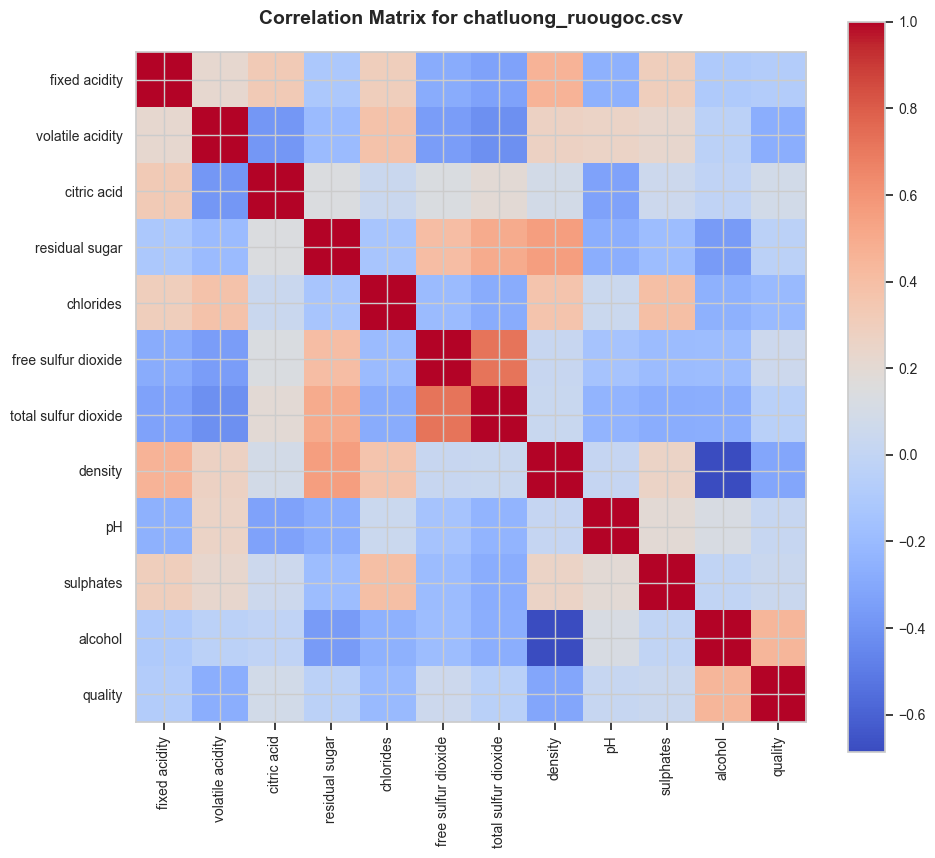

In [1]:
plotCorrelationMatrix(df1, 10)

## 5. Ma Trận Phân Tán và Đường Mật Độ (Scatter and Density Plots)
Biểu đồ phân tán (scatter) từng cặp biến, đường mật độ nhân KDE trên đường chéo và hệ số tương quan ở nửa trên tam giác ma trận.

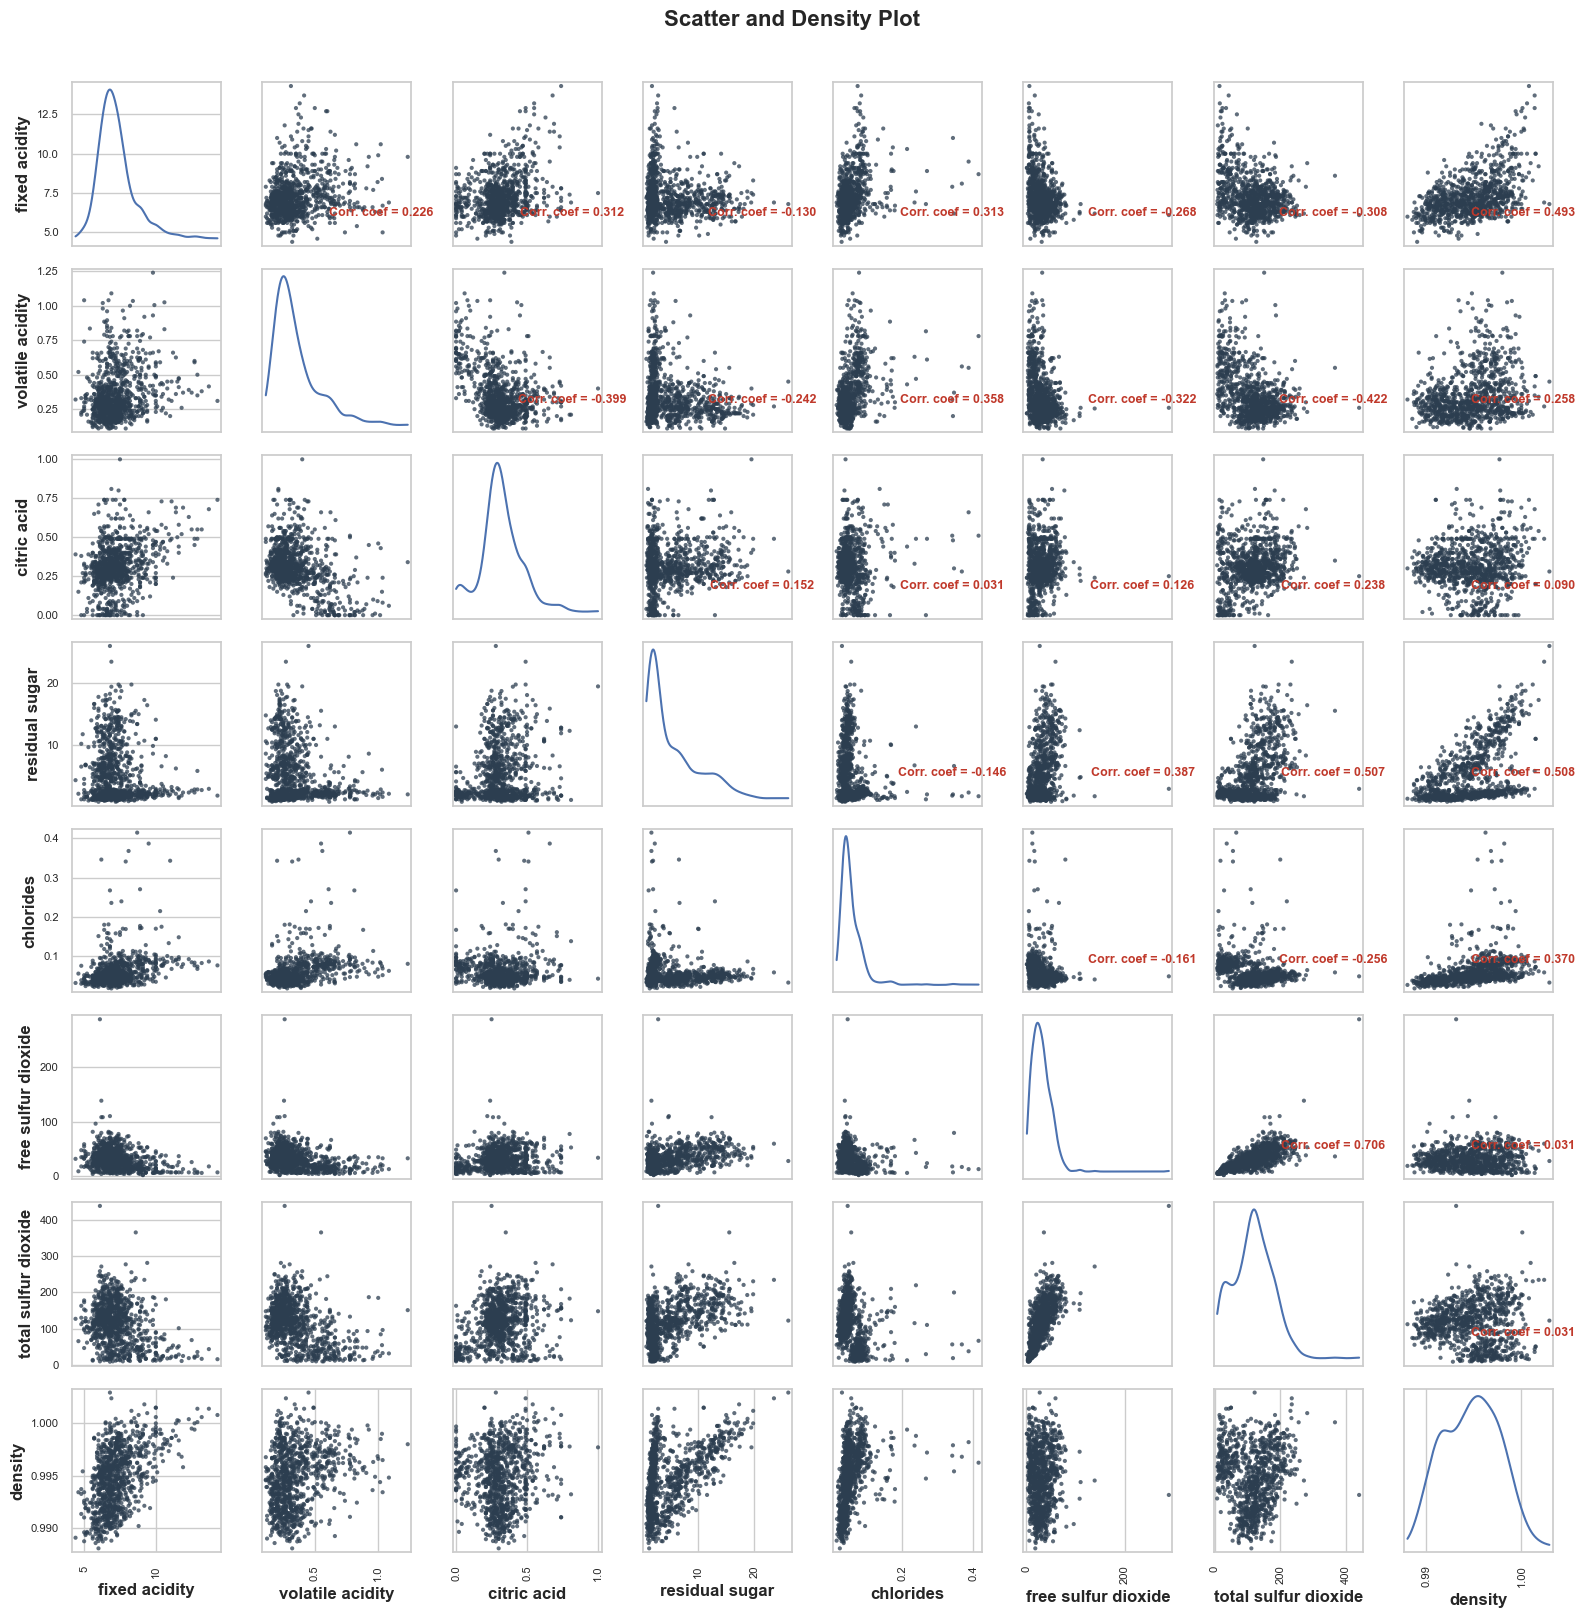

In [1]:
plotScatterMatrix(df1, 16, 9)

## 6. Phân Tích Chuyên Sâu Chất Lượng Rượu Vang (Dữ Liệu Chuẩn Hóa)
Khám phá phân phối theo 3 bậc chất lượng (*Kém - Trung bình - Thượng hạng*) và các yếu tố then chốt.

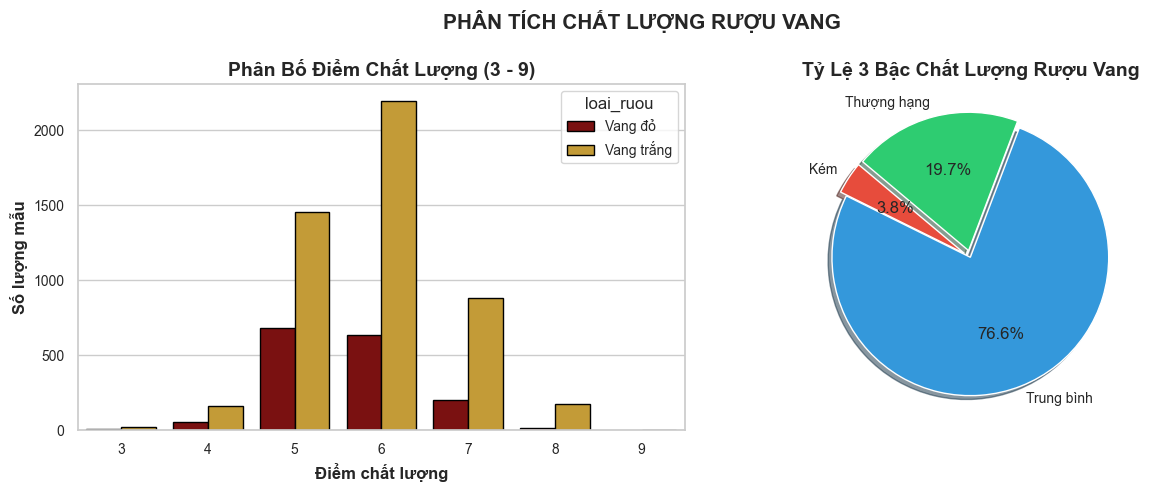

In [1]:
df_chuan = doc_du_lieu_chuan()
ve_phan_phoi_chat_luong(df_chuan)
plt.show()

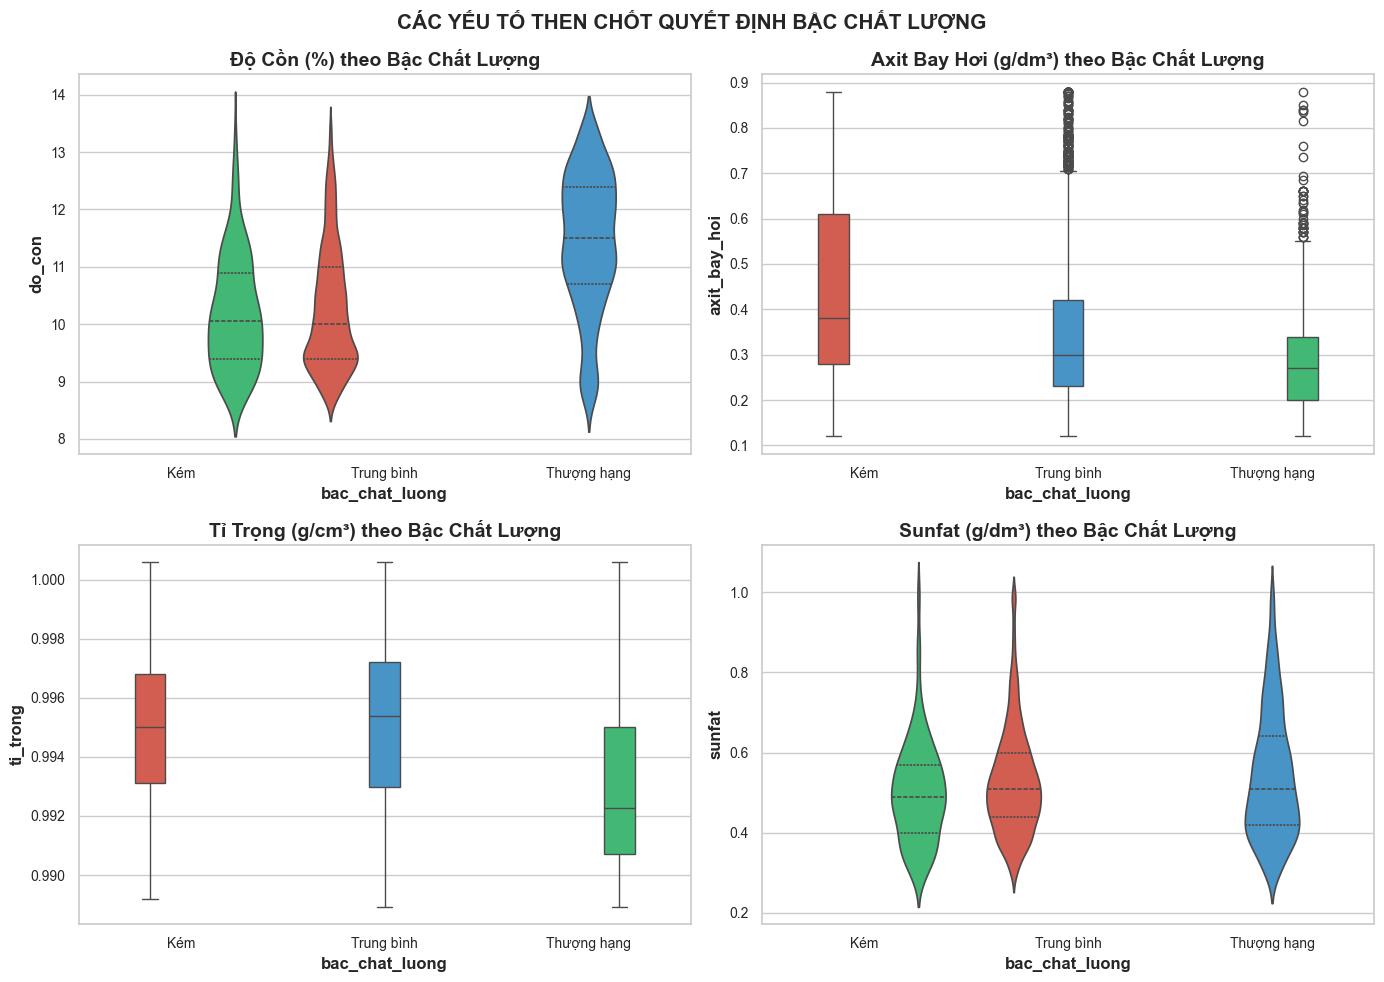

In [1]:
ve_yeu_to_quyet_dinh_chat_luong(df_chuan)
plt.show()

### Đúc Kết Insight:
1. **Phân phối:** Đa số các chỉ số (độ cồn, đường dư, axit bay hơi) có phân phối lệch phải.
2. **Tương quan:** Độ cồn có tương quan dương mạnh nhất với chất lượng, trong khi axit bay hơi có tương quan âm mạnh nhất.
3. **Mật độ phân tán:** Rượu chất lượng cao tập trung ở góc độ cồn cao (>11%) và axit bay hơi thấp (<0.35 g/dm³).